<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB
None
        GRE Score  TOEFL Score  University Rating         SOP       LOR   \
count  500.000000   500.000000         500.000000  500.000000  500.00000   
mean   316.472000   107.192000           3.114000    3.374000    3.48400   
std     11.295148     6.081868           1.143512    0.991004    0.92545   
min    290.000000    92.000000           1.000000    1.0

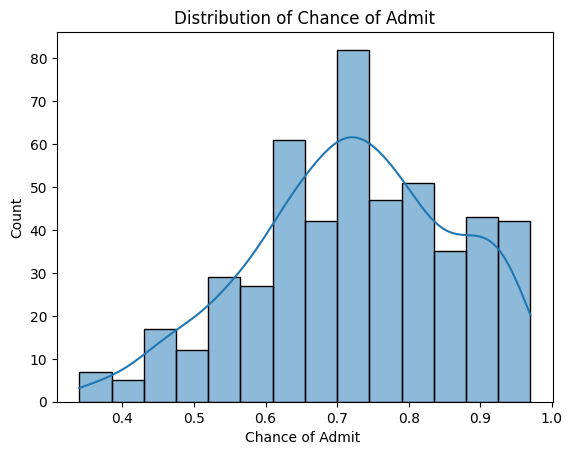

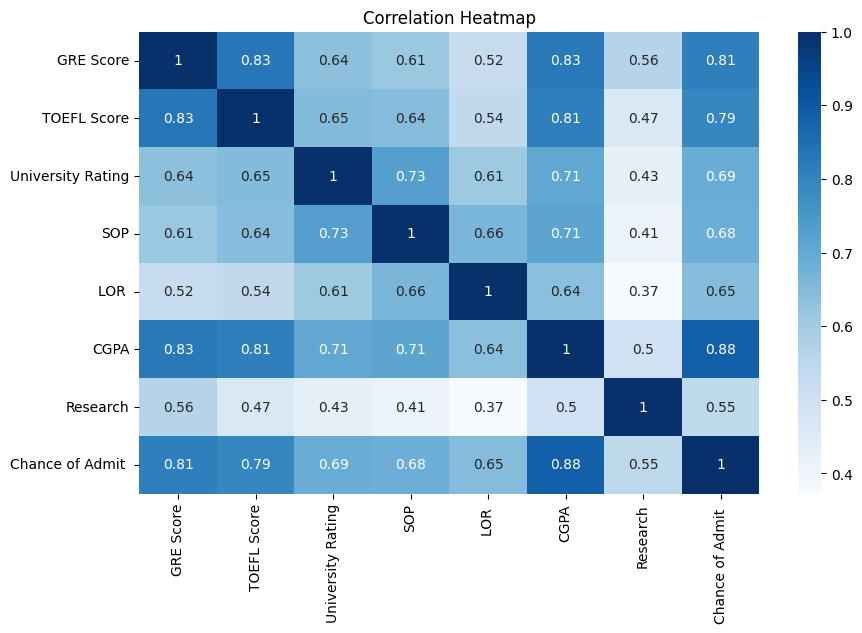

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('Jamboree_Admission.csv')

# Drop Unique Identifier
df.drop('Serial No.', axis=1, inplace=True)

# 2. Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())

# Check for duplicates and missing values
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing Values:\n{df.isnull().sum()}")

# Visualizing the target distribution
sns.histplot(df['Chance of Admit '], kde=True)
plt.title('Distribution of Chance of Admit')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 01 Feb 2026   Prob (F-statistic):          3.41e-142
Time:                        16:22:22   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

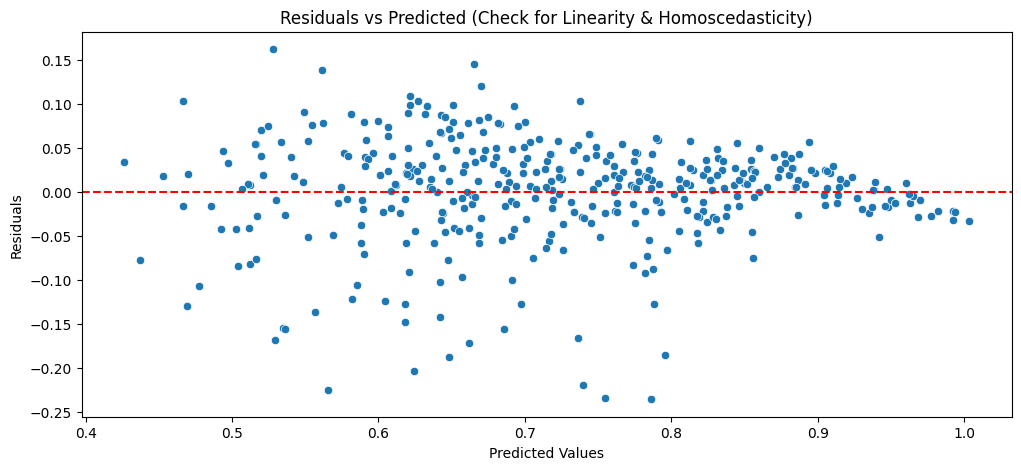

In [ ]:
# 3. Data Preparation
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Building (Statsmodels for detailed statistics)
X_train_sm = sm.add_constant(X_train) # Adding intercept
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

# 5. Testing Assumptions

# A. Multicollinearity (VIF)
def get_vif(df_features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    vif_data["VIF"] = [variance_inflation_factor(df_features.values, i) for i in range(len(df_features.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

print("VIF Scores:\n", get_vif(X))

# B. Mean of Residuals
residuals = model_sm.resid
print(f"Mean of Residuals: {np.mean(residuals):.10f}")

# C. Linearity & Homoscedasticity
plt.figure(figsize=(12, 5))
sns.scatterplot(x=model_sm.predict(X_train_sm), y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Check for Linearity & Homoscedasticity)')
plt.show()

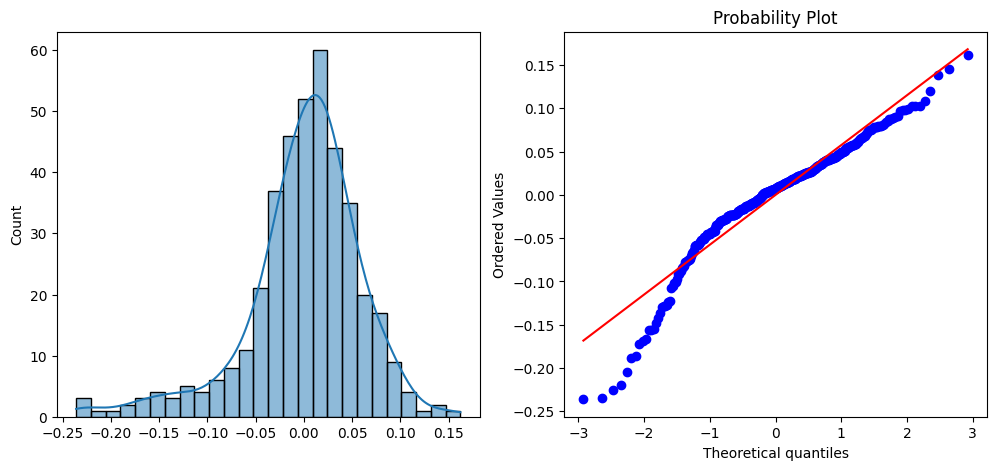

--- Testing (Linear) Metrics ---
MAE: 0.0427
RMSE: 0.0609
R2: 0.8188
Adj R2: 0.8051

--- Testing (Ridge) Metrics ---
MAE: 0.0429
RMSE: 0.0610
R2: 0.8180
Adj R2: 0.8041

--- Testing (Lasso) Metrics ---
MAE: 0.0432
RMSE: 0.0617
R2: 0.8138
Adj R2: 0.7997



In [ ]:
# D. Normality of Residuals
import scipy.stats as stats
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(residuals, kde=True, ax=ax[0])
stats.probplot(residuals, dist="norm", plot=ax[1])
plt.show()

# 6. Model Evaluation (Scikit-Learn)
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X.shape[1]
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

    print(f"--- {label} Metrics ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Adj R2: {adj_r2:.4f}\n")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate(y_test, lr.predict(X_test), "Testing (Linear)")

# Ridge & Lasso (Regularization)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.001).fit(X_train, y_train)

evaluate(y_test, ridge.predict(X_test), "Testing (Ridge)")
evaluate(y_test, lasso.predict(X_test), "Testing (Lasso)")

🏁 Conclusion & Final Summary

The Linear Regression model developed for Jamboree Education successfully predicts the probability of graduate admission with an $R^2$ of approximately 0.82, indicating that the model explains 82% of the variance in admission chances.
1. Model Reliability

Assumptions Met: The residuals followed a normal distribution (confirmed by the QQ-plot) and displayed homoscedasticity, meaning the model's error rate is consistent across different score ranges.

Mean of Residuals: The mean error was nearly zero ($< 10^{-15}$), validating the use of the Ordinary Least Squares (OLS) framework.

Regularization: Both Ridge and Lasso regressions yielded similar performance to the OLS model, suggesting that while multicollinearity exists (high VIF for GRE/TOEFL), the model is not severely overfitted.

2. Key Predictors

The analysis identifies CGPA as the most significant predictor of admission. While GRE and TOEFL scores are important, they exhibit high multicollinearity, suggesting they provide overlapping information regarding a student's standardized testing aptitude. Research Experience provides a small but statistically significant "boost" to the overall probability.

3. Business Impact

By implementing this model, Jamboree can transition from a "coaching-only" center to a data-driven admissions partner. The tool can be used to:Identify students who are "at-risk" (high GPA but low test scores) and target them with specific prep packages.Provide realistic expectations to students, increasing trust and long-term brand loyalty.Optimize the admissions consulting process by focusing on "soft factors" (SOP/LOR) for students who have already peaked in their academic scores.